# MatForge — Notebook 02: DataLoader and Augmentation Pipeline
#
# Validates the full data pipeline before training:
# - Stratified 85/15 train/val split persisted as CSV (generated once, frozen)
# - WeightedRandomSampler with correct per-texture weights from relabeling
# - Coherent geometric augmentations for Normal maps (tangent-space OpenGL)
# - On-the-fly Metallic map generation for non-metal textures
# - Normalisation consistent with MiT-B1 ImageNet pretraining

## Cell 1 — Imports and paths

In [1]:
import os
import json
import math
import random
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image
 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
DATASET_ROOT  = Path("/kaggle/input/datasets/mjgut05/matforge-pbr-dataset")
RGB_DIR       = DATASET_ROOT / "maps" / "rgb"
NORMAL_DIR    = DATASET_ROOT / "maps" / "normal"
ROUGHNESS_DIR = DATASET_ROOT / "maps" / "roughness"
METALLIC_DIR  = DATASET_ROOT / "maps" / "metallic"
RELABELING_CSV  = DATASET_ROOT / "relabeling" / "relabeling_final.csv"
SAMPLER_WEIGHTS = DATASET_ROOT / "relabeling" / "sampler_weights.json"
 
OUTPUT_DIR = Path("/kaggle/working")
SPLIT_CSV  = OUTPUT_DIR / "matforge_split.csv"
 
CROP_SIZE     = 256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
# Column names as they exist in relabeling_final.csv
COL_FILENAME = "filename"           # e.g. "ceramic_0000.png"
COL_GROUP    = "functional_group"   # e.g. "mixed_ambiguous"
 
print(f"Device : {DEVICE}")
print(f"Dataset: {DATASET_ROOT}")

Device : cuda
Dataset: /kaggle/input/datasets/mjgut05/matforge-pbr-dataset


## Cell 2 — Verify dataset structure

In [2]:
def verify_dataset_structure() -> pd.DataFrame:
    """
    Checks that all required paths exist and that the CSV columns
    match what the rest of the pipeline expects. Fails fast with a
    descriptive message rather than a cryptic error downstream.
    """
    required = [
        RGB_DIR, NORMAL_DIR, ROUGHNESS_DIR, METALLIC_DIR,
        RELABELING_CSV, SAMPLER_WEIGHTS,
    ]
    all_ok = True
    for p in required:
        status = "OK" if p.exists() else "MISSING"
        print(f"  [{status}] {p}")
        if not p.exists():
            all_ok = False
 
    assert all_ok, "One or more required paths are missing."
 
    rgb_files = list(RGB_DIR.glob("*.png"))
    print(f"\n  RGB textures found : {len(rgb_files)}")
    assert len(rgb_files) > 3000, f"Expected >3000 RGB textures, found {len(rgb_files)}"
 
    df = pd.read_csv(RELABELING_CSV)
    print(f"  Relabeling CSV rows: {len(df)}")
    print(f"  Columns            : {list(df.columns)}")
 
    assert COL_FILENAME in df.columns, \
        f"Expected column '{COL_FILENAME}' not found. Got: {list(df.columns)}"
    assert COL_GROUP in df.columns, \
        f"Expected column '{COL_GROUP}' not found. Got: {list(df.columns)}"
 
    print(f"  Groups             : {sorted(df[COL_GROUP].unique())}")
    print("\nDataset structure: OK")
    return df
 
 
df_labels = verify_dataset_structure()

  [OK] /kaggle/input/datasets/mjgut05/matforge-pbr-dataset/maps/rgb
  [OK] /kaggle/input/datasets/mjgut05/matforge-pbr-dataset/maps/normal
  [OK] /kaggle/input/datasets/mjgut05/matforge-pbr-dataset/maps/roughness
  [OK] /kaggle/input/datasets/mjgut05/matforge-pbr-dataset/maps/metallic
  [OK] /kaggle/input/datasets/mjgut05/matforge-pbr-dataset/relabeling/relabeling_final.csv
  [OK] /kaggle/input/datasets/mjgut05/matforge-pbr-dataset/relabeling/sampler_weights.json

  RGB textures found : 3245
  Relabeling CSV rows: 3245
  Columns            : ['filename', 'original_category', 'cluster_id', 'functional_group', 'needs_review']
  Groups             : ['brick_terracotta', 'ceramic_ground', 'concrete_plaster', 'marble_smooth', 'metal', 'mixed_ambiguous', 'stone_rough', 'wood']

Dataset structure: OK


## Cell 3 — Inspect relabeling CSV and sampler weights

In [3]:
def inspect_labels(df: pd.DataFrame) -> dict:
    """
    Summarises group distribution and verifies that sampler weights exist
    for every texture in the relabeling CSV.
    """
    print("Group distribution:")
    counts = df[COL_GROUP].value_counts().sort_index()
    for group, count in counts.items():
        pct = count / len(df) * 100
        print(f"  {group:<25} {count:>4}  ({pct:.1f}%)")
 
    with open(SAMPLER_WEIGHTS) as f:
        weights = json.load(f)
 
    print(f"\nSampler weight entries : {len(weights)}")
 
    filenames_csv     = set(df[COL_FILENAME].astype(str))
    filenames_weights = set(weights.keys())
    missing = filenames_csv - filenames_weights
    assert not missing, \
        f"{len(missing)} textures in CSV have no sampler weight. Sample: {list(missing)[:3]}"
 
    unique_weights = sorted(set(weights.values()))
    print(f"Unique weight values   : {unique_weights}")
    print("\nLabel inspection: OK")
    return weights
 
 
sampler_weights_dict = inspect_labels(df_labels)

Group distribution:
  brick_terracotta           276  (8.5%)
  ceramic_ground             503  (15.5%)
  concrete_plaster           127  (3.9%)
  marble_smooth              189  (5.8%)
  metal                      238  (7.3%)
  mixed_ambiguous            775  (23.9%)
  stone_rough                479  (14.8%)
  wood                       658  (20.3%)

Sampler weight entries : 3245
Unique weight values   : [0.5, 1.0, 1.2, 1.3]

Label inspection: OK


## Cell 4 — Generate and persist the frozen train/val split
#
# Generated once with SEED=42 and saved to /kaggle/working/matforge_split.csv.
# All training notebooks must load this file — never regenerate it — so that
# no validation texture ever leaks into training across experiments.

In [4]:
def build_stratified_split(
    df: pd.DataFrame,
    val_fraction: float = 0.15,
    seed: int = SEED,
) -> pd.DataFrame:
    """
    Stratified 85/15 split by functional group.
 
    Stratification ensures that even the smallest group (concrete_plaster, 127
    textures) contributes proportionally to the validation set. A purely random
    split could leave rare groups entirely in training.
    """
    rng    = np.random.default_rng(seed)
    splits = []
 
    for group, group_df in df.groupby(COL_GROUP):
        idx = group_df.index.to_numpy().copy()
        rng.shuffle(idx)
        n_val   = max(1, int(len(idx) * val_fraction))
        val_idx = idx[:n_val]
        trn_idx = idx[n_val:]
        splits.append(group_df.loc[trn_idx].assign(split="train"))
        splits.append(group_df.loc[val_idx].assign(split="val"))
 
    df_split = pd.concat(splits).sort_index().reset_index(drop=True)
    df_split.to_csv(SPLIT_CSV, index=False)
 
    n_train = (df_split["split"] == "train").sum()
    n_val   = (df_split["split"] == "val").sum()
    print(f"Split saved: {SPLIT_CSV}")
    print(f"  Train : {n_train}  ({n_train / len(df_split) * 100:.1f}%)")
    print(f"  Val   : {n_val}   ({n_val   / len(df_split) * 100:.1f}%)")
    print("\nPer-group breakdown:")
    for group, gdf in df_split.groupby(COL_GROUP):
        n_tr = (gdf["split"] == "train").sum()
        n_vl = (gdf["split"] == "val").sum()
        print(f"  {group:<25} train={n_tr:>3}  val={n_vl:>3}")
 
    return df_split
 
 
if SPLIT_CSV.exists():
    print(f"Split CSV already exists — loading without regenerating.")
    df_split = pd.read_csv(SPLIT_CSV)
    n_train = (df_split["split"] == "train").sum()
    n_val   = (df_split["split"] == "val").sum()
    print(f"  Train: {n_train}  Val: {n_val}")
else:
    df_split = build_stratified_split(df_labels)

Split saved: /kaggle/working/matforge_split.csv
  Train : 2762  (85.1%)
  Val   : 483   (14.9%)

Per-group breakdown:
  brick_terracotta          train=235  val= 41
  ceramic_ground            train=428  val= 75
  concrete_plaster          train=108  val= 19
  marble_smooth             train=161  val= 28
  metal                     train=203  val= 35
  mixed_ambiguous           train=659  val=116
  stone_rough               train=408  val= 71
  wood                      train=560  val= 98


## Cell 5 — Augmentation functions

In [5]:
def apply_geometric_augmentation(
    rgb: torch.Tensor,
    normal: torch.Tensor,
    roughness: torch.Tensor,
    metallic: torch.Tensor,
    p_hflip: float = 0.5,
    p_vflip: float = 0.5,
) -> tuple:
    """
    Applies spatially consistent geometric augmentations to all four maps.
 
    Normal maps require component-level transformations in addition to the
    spatial operation, because the stored (X, Y, Z) vector encodes surface
    orientation in tangent space (OpenGL convention, +Z outward).
 
    Transformation rules for N = (X, Y, Z):
        Horizontal flip  : (-X,  Y, Z)
        Vertical flip    : ( X, -Y, Z)
        Rotation 90° CCW : (-Y,  X, Z)
        Rotation 180°    : (-X, -Y, Z)
        Rotation 270° CCW: ( Y, -X, Z)
 
    Scalar maps (roughness, metallic) only receive the spatial transform.
    Rotations are restricted to multiples of 90° to avoid interpolation
    artefacts on fine normal/roughness detail and to respect directional
    anisotropy in materials such as wood grain.
    """
    if torch.rand(1).item() < p_hflip:
        rgb       = TF.hflip(rgb)
        roughness = TF.hflip(roughness)
        metallic  = TF.hflip(metallic)
        normal    = TF.hflip(normal)
        normal    = torch.cat([-normal[0:1], normal[1:2], normal[2:3]], dim=0)
 
    if torch.rand(1).item() < p_vflip:
        rgb       = TF.vflip(rgb)
        roughness = TF.vflip(roughness)
        metallic  = TF.vflip(metallic)
        normal    = TF.vflip(normal)
        normal    = torch.cat([normal[0:1], -normal[1:2], normal[2:3]], dim=0)
 
    k = torch.randint(0, 4, (1,)).item()
    if k > 0:
        rgb       = torch.rot90(rgb,       k, dims=[1, 2])
        roughness = torch.rot90(roughness, k, dims=[1, 2])
        metallic  = torch.rot90(metallic,  k, dims=[1, 2])
        normal    = torch.rot90(normal,    k, dims=[1, 2])
        x, y, z   = normal[0:1], normal[1:2], normal[2:3]
        if k == 1:
            normal = torch.cat([-y,  x, z], dim=0)
        elif k == 2:
            normal = torch.cat([-x, -y, z], dim=0)
        elif k == 3:
            normal = torch.cat([ y, -x, z], dim=0)
 
    return rgb, normal, roughness, metallic
 
 
def apply_photometric_augmentation(rgb: torch.Tensor) -> torch.Tensor:
    """
    Mild photometric perturbations applied only to the RGB input.
 
    Ranges are conservative to avoid introducing input-GT pairs that are
    physically inconsistent. The GT maps are recorded under the true material
    appearance; strong colour jitter would teach the model spurious correlations
    between perturbed colour and unperturbed roughness/normal.
    """
    pil = TF.to_pil_image(rgb)
    pil = transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
        saturation=0.05,
        hue=0.02,
    )(pil)
    return TF.to_tensor(pil)
 
 
print("Augmentation functions defined.")

Augmentation functions defined.


## Cell 6 — Dataset class

In [6]:
class MatForgeDataset(Dataset):
    """
    PyTorch Dataset for MatForge PBR material textures.
 
    Each sample returns:
        rgb      : (3, H, W) float32, ImageNet-normalised
        normal   : (3, H, W) float32, range [-1, 1]
        roughness: (1, H, W) float32, range [0, 1]
        metallic : (1, H, W) float32, range [0, 1]
        group    : str, functional group label
 
    Metallic is loaded from disk only for the 'metal' functional group.
    For all other groups it is generated as a zero tensor at runtime,
    which is the physically correct default for dielectric materials in
    the UE4 metallic/roughness workflow.
 
    RGB is normalised with ImageNet mean/std because MiT-B1 is pretrained
    on ImageNet-1K. Using dataset-specific statistics would break the
    pretrained feature representations in the encoder.
 
    Normal maps are stored in PNG as (N + 1) / 2 to fit the [0, 255] range
    and are remapped back to [-1, 1] during loading.
    """
 
    _MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    _STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
 
    def __init__(
        self,
        df: pd.DataFrame,
        split: str,
        crop_size: int = 256,
        augment: bool = True,
    ):
        assert split in ("train", "val"), f"split must be 'train' or 'val', got '{split}'"
        self.df        = df[df["split"] == split].reset_index(drop=True)
        self.split     = split
        self.crop_size = crop_size
        self.augment   = augment and (split == "train")
 
    def __len__(self) -> int:
        return len(self.df)
 
    @staticmethod
    def _load(path: Path, mode: str) -> torch.Tensor:
        return TF.to_tensor(Image.open(path).convert(mode))
 
    def __getitem__(self, idx: int) -> dict:
        row      = self.df.iloc[idx]
        filename = str(row[COL_FILENAME])
        group    = str(row[COL_GROUP])
 
        rgb       = self._load(RGB_DIR       / filename, "RGB")
        normal_01 = self._load(NORMAL_DIR    / filename, "RGB")
        roughness = self._load(ROUGHNESS_DIR / filename, "L")
 
        metal_path = METALLIC_DIR / filename
        if group == "metal" and metal_path.exists():
            metallic = self._load(metal_path, "L")
        else:
            metallic = torch.zeros(1, rgb.shape[1], rgb.shape[2])
 
        # Remap from PNG storage range [0, 1] to tangent-space range [-1, 1]
        normal = normal_01 * 2.0 - 1.0
 
        # Identical random crop applied to all maps simultaneously
        i, j, h, w = transforms.RandomCrop.get_params(
            rgb, output_size=(self.crop_size, self.crop_size)
        )
        rgb       = TF.crop(rgb,       i, j, h, w)
        normal    = TF.crop(normal,    i, j, h, w)
        roughness = TF.crop(roughness, i, j, h, w)
        metallic  = TF.crop(metallic,  i, j, h, w)
 
        if self.augment:
            rgb, normal, roughness, metallic = apply_geometric_augmentation(
                rgb, normal, roughness, metallic
            )
            rgb = apply_photometric_augmentation(rgb)
 
        rgb = (rgb - self._MEAN) / self._STD
 
        return {
            "rgb":       rgb,
            "normal":    normal,
            "roughness": roughness,
            "metallic":  metallic,
            "group":     group,
        }
 
 
print("Dataset class defined.")

Dataset class defined.


## Cell 7 — Build DataLoaders

In [7]:
def build_loaders(
    df_split: pd.DataFrame,
    weights_dict: dict,
    batch_size: int = 8,
    num_workers: int = 2,
    crop_size: int = 256,
) -> tuple:
    """
    Constructs train and validation DataLoaders.
 
    WeightedRandomSampler controls long-run group frequency using the
    per-texture weights from sampler_weights.json. This gives the metal
    group a higher base sampling rate than its raw 7.3% share.
 
    The guaranteed 2-metal-per-batch constraint is enforced in the training
    loop (notebook 03), not here. The DataLoader is stateless with respect
    to batch composition; the training loop resamples from a separate
    metal-only index when needed.
 
    Validation uses a standard sequential sampler with no augmentation.
    """
    df_train = df_split[df_split["split"] == "train"].reset_index(drop=True)
 
    train_weights = torch.tensor(
        [weights_dict[str(row[COL_FILENAME])] for _, row in df_train.iterrows()],
        dtype=torch.float32,
    )
 
    sampler = WeightedRandomSampler(
        weights=train_weights,
        num_samples=len(df_train),
        replacement=True,
    )
 
    ds_train = MatForgeDataset(df_split, "train", crop_size=crop_size, augment=True)
    ds_val   = MatForgeDataset(df_split, "val",   crop_size=crop_size, augment=False)
 
    dl_train = DataLoader(
        ds_train,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True,
    )
    dl_val = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False,
    )
 
    print(f"Train : {len(ds_train)} samples, {len(dl_train)} batches")
    print(f"Val   : {len(ds_val)} samples,  {len(dl_val)} batches")
    return dl_train, dl_val, ds_train, ds_val
 
 
dl_train, dl_val, ds_train, ds_val = build_loaders(
    df_split, sampler_weights_dict, batch_size=8, num_workers=2
)

Train : 2762 samples, 345 batches
Val   : 483 samples,  61 batches


## Cell 8 — Tensor shape, dtype and range validation

In [8]:
def test_batch(dl: DataLoader, label: str):
    """
    Loads one batch and verifies shapes, dtypes, and value ranges.
    A failure here indicates a preprocessing bug that would corrupt training.
    """
    batch = next(iter(dl))
    B = batch["rgb"].shape[0]
 
    print(f"\n{label} batch (B={B}):")
    for name in ["rgb", "normal", "roughness", "metallic"]:
        t = batch[name]
        print(f"  {name:<10}: shape={tuple(t.shape)}  dtype={t.dtype}  "
              f"range=[{t.min():.3f}, {t.max():.3f}]")
 
    rgb, normal, roughness, metallic = (
        batch["rgb"], batch["normal"], batch["roughness"], batch["metallic"]
    )
 
    assert rgb.shape       == (B, 3, 256, 256)
    assert normal.shape    == (B, 3, 256, 256)
    assert roughness.shape == (B, 1, 256, 256)
    assert metallic.shape  == (B, 1, 256, 256)
 
    for name, t in [("rgb", rgb), ("normal", normal),
                    ("roughness", roughness), ("metallic", metallic)]:
        assert t.dtype == torch.float32, f"{name} must be float32"
        assert not torch.isnan(t).any(), f"NaN in {name}"
 
    assert roughness.min() >= 0.0 and roughness.max() <= 1.0
    assert metallic.min()  >= 0.0 and metallic.max()  <= 1.0
    assert normal.min()    >= -1.0 and normal.max()   <= 1.0
 
    print(f"  groups : {batch['group']}")
    print(f"  Shape / dtype / range: PASS")
 
 
test_batch(dl_train, "TRAIN")
test_batch(dl_val,   "VAL")


TRAIN batch (B=8):
  rgb       : shape=(8, 3, 256, 256)  dtype=torch.float32  range=[-1.983, 2.222]
  normal    : shape=(8, 3, 256, 256)  dtype=torch.float32  range=[-0.906, 1.000]
  roughness : shape=(8, 1, 256, 256)  dtype=torch.float32  range=[0.020, 1.000]
  metallic  : shape=(8, 1, 256, 256)  dtype=torch.float32  range=[0.000, 0.000]
  groups : ['ceramic_ground', 'brick_terracotta', 'ceramic_ground', 'brick_terracotta', 'mixed_ambiguous', 'wood', 'wood', 'marble_smooth']
  Shape / dtype / range: PASS

VAL batch (B=8):
  rgb       : shape=(8, 3, 256, 256)  dtype=torch.float32  range=[-2.118, 2.570]
  normal    : shape=(8, 3, 256, 256)  dtype=torch.float32  range=[-1.000, 1.000]
  roughness : shape=(8, 1, 256, 256)  dtype=torch.float32  range=[0.000, 1.000]
  metallic  : shape=(8, 1, 256, 256)  dtype=torch.float32  range=[0.000, 0.000]
  groups : ['ceramic_ground', 'wood', 'mixed_ambiguous', 'mixed_ambiguous', 'ceramic_ground', 'mixed_ambiguous', 'metal', 'mixed_ambiguous']
  Shape

## Cell 9 — Sampler balance verification

In [9]:
def verify_sampler_balance(dl: DataLoader, n_batches: int = 50):
    """
    Measures empirical group frequency over n_batches.
    Metal must appear at > 3% to avoid Metallic head collapse.
    """
    from collections import Counter
    counts = Counter()
 
    for i, batch in enumerate(dl):
        if i >= n_batches:
            break
        for g in batch["group"]:
            counts[g] += 1
 
    total = sum(counts.values())
    print(f"Group frequencies over {n_batches} batches ({total} samples):")
    for group in sorted(counts):
        pct = counts[group] / total * 100
        marker = " <<<" if group == "metal" else ""
        print(f"  {group:<25} {counts[group]:>4}  ({pct:.1f}%){marker}")
 
    metal_pct = counts.get("metal", 0) / total * 100
    assert metal_pct > 3.0, \
        f"Metal frequency {metal_pct:.1f}% is below threshold — check sampler weights"
    print(f"\nMetal at {metal_pct:.1f}% (threshold: >3%)  —  Sampler balance: OK")
 
 
verify_sampler_balance(dl_train)

Group frequencies over 50 batches (400 samples):
  brick_terracotta            41  (10.2%)
  ceramic_ground              65  (16.2%)
  concrete_plaster            14  (3.5%)
  marble_smooth               29  (7.2%)
  metal                       44  (11.0%) <<<
  mixed_ambiguous             49  (12.2%)
  stone_rough                 61  (15.2%)
  wood                        97  (24.2%)

Metal at 11.0% (threshold: >3%)  —  Sampler balance: OK


## Cell 10 — Visual inspection of augmentations

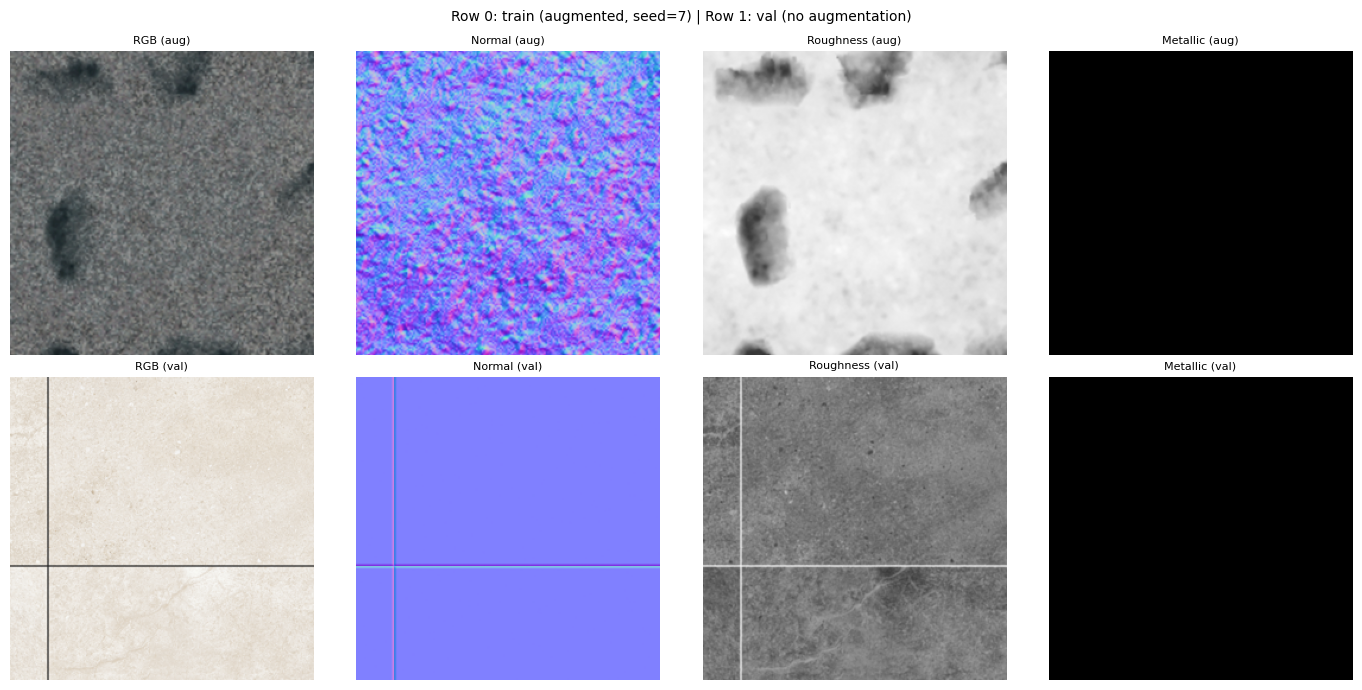

In [10]:
def visualise_augmentations():
    """
    Shows the same texture under one augmented variant (train) and the
    clean variant (val) across all four maps.
 
    What to check:
    - All four maps apply the same spatial transform.
    - Normal map colour shifts with rotations — correct, reflects the
      component-level channel transform (X, Y signs change).
    - Val row shows no colour jitter and matches the unaugmented source.
    """
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle(
        "Row 0: train (augmented, seed=7) | Row 1: val (no augmentation)",
        fontsize=10
    )
 
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
 
    def show_rgb(ax, t, title):
        img = (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img); ax.set_title(title, fontsize=8); ax.axis("off")
 
    def show_normal(ax, t, title):
        img = ((t + 1.0) / 2.0).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img); ax.set_title(title, fontsize=8); ax.axis("off")
 
    def show_scalar(ax, t, title):
        ax.imshow(t.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(title, fontsize=8); ax.axis("off")
 
    torch.manual_seed(7)
    sample_tr = ds_train[0]
    sample_va = ds_val[0]
 
    show_rgb(   axes[0][0], sample_tr["rgb"],       "RGB (aug)")
    show_normal(axes[0][1], sample_tr["normal"],    "Normal (aug)")
    show_scalar(axes[0][2], sample_tr["roughness"], "Roughness (aug)")
    show_scalar(axes[0][3], sample_tr["metallic"],  "Metallic (aug)")
 
    show_rgb(   axes[1][0], sample_va["rgb"],       "RGB (val)")
    show_normal(axes[1][1], sample_va["normal"],    "Normal (val)")
    show_scalar(axes[1][2], sample_va["roughness"], "Roughness (val)")
    show_scalar(axes[1][3], sample_va["metallic"],  "Metallic (val)")
 
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "augmentation_check.png", dpi=120, bbox_inches="tight")
    plt.show()
 
 
visualise_augmentations()

## Cell 11 — Normal map Z-component coherence test

In [11]:
def test_normal_z_coherence(n_samples: int = 50):
    """
    Verifies that augmentations never produce a normal map where the majority
    of pixels have a negative Z component.
 
    In tangent-space OpenGL, Z > 0 means the surface faces toward the camera.
    A predominantly negative Z after augmentation would indicate a bug in the
    component transformation logic (e.g. sign applied to the wrong channel).
    """
    n_neg_z = 0
    for idx in range(min(n_samples, len(ds_train))):
        torch.manual_seed(idx)
        sample = ds_train[idx]
        z_chan = sample["normal"][2]
        if (z_chan < 0).float().mean() > 0.5:
            n_neg_z += 1
 
    print(f"Samples tested              : {n_samples}")
    print(f"Samples with majority -Z    : {n_neg_z}  (expected: 0)")
    assert n_neg_z == 0, \
        f"{n_neg_z} samples have predominantly negative Z — check component transform"
    print("Normal Z coherence: PASS")
 
 
test_normal_z_coherence()

Samples tested              : 50
Samples with majority -Z    : 0  (expected: 0)
Normal Z coherence: PASS


## Cell 12 — Throughput benchmark

In [12]:
def benchmark_dataloader(dl: DataLoader, n_batches: int = 20):
    """
    Measures DataLoader I/O throughput at training batch size.
    Target: < 500 ms per batch to avoid GPU starvation during training.
    If throughput exceeds this threshold, increase num_workers or
    enable persistent_workers=True in the training notebook.
    """
    import time
 
    for i, _ in enumerate(dl):
        if i >= 2:
            break
 
    times = []
    for i, batch in enumerate(dl):
        if i >= n_batches:
            break
        t0 = time.perf_counter()
        _ = batch["rgb"].to(DEVICE, non_blocking=True)
        torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)
 
    mean_ms = float(np.mean(times))
    status  = "OK" if mean_ms < 500 else "SLOW"
    print(f"[{status}] {mean_ms:.1f} ± {float(np.std(times)):.1f} ms/batch  "
          f"(max={max(times):.1f}  min={min(times):.1f})")
 
    if mean_ms > 500:
        print("  Recommendation: num_workers=4, persistent_workers=True")
 
 
benchmark_dataloader(dl_train)

[OK] 0.9 ± 1.1 ms/batch  (max=5.6  min=0.6)


## Summary
#
# If all cells passed:
# - matforge_split.csv is ready in /kaggle/working — save it as a notebook output.